# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nathaniela Isya Nur Rofia
- **Email:** nielaisya@gmail.com
- **ID Dicoding:** CDCC179D6X0606

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penggunaan sepeda berdasarkan musin dan kondisi cuaca? Apakah musim dan cuaca secara signifikan memengaruhi jumlah peminjaman sepeda?
- Bagaimana perbedaan pola peminjaman sepeda antara hari kerja dan hari libur berdasarkan jam? kapan jam-jam puncak peminjaman terjadi?

## Import Semua Packages/Library yang Digunakan

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Data Wrangling

### Gathering Data

In [79]:
#Load data day.csv
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [80]:
#load data hour.csv
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
-  Mengetahui data agregat harian yang dapat digunakan untuk mengetahui tren jangka panjang, pengaruh musin, atau perbedaan performa antar tahun.
- Mengetahui data tingkat jam yang digunakan untuk menganalisis jam sibuk untuk menentukan kapan permintaan sepeda mencapai titik tertinggi.


### Assessing Data

In [81]:
#Cek informasi data day.csv
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [82]:
#Cek nilai kosong pada data day.csv
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [83]:
#Cek data duplikat pada data day.csv
day_df.duplicated().sum()

np.int64(0)

In [84]:
#Cek deskriptive statistika data day.csv
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [85]:
#Cek informasi data hour.csv
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [86]:
#Cek nilai kosong pada data hour.csv
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [87]:
#Cek data duplikat pada data hour.csv
hour_df.duplicated().sum()

np.int64(0)

In [88]:
#Cek deskriptive statistika data hour.csv
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dataset day dan hour merupakan dataset yang lengkap atau tidak terdapat missing value dan tidak terdapat duplikat. Sehingga dapat tersebut tergolong data yang baik untuk analisis lebih lanjut.
- Namun variabel dteday pada masing-masing data masih bertipe data object, sehingga perlu diganti ke format datetime agar dapat digunaakn dalam analisis berbasis waktu.
-Beberapa kolom kategorikal, perlu dilakukan mapping ke label yang lebih deskriptif.


### Cleaning Data

In [89]:
#Ubah tipe data dteday pada data day.csv
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [90]:
#Ubah tipe data dteday pada data hour.csv
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [91]:
#Lakukan mapping untuk data kategorik
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
               4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
yr_map = {0: 2011, 1: 2012}

In [92]:
for df in [day_df, hour_df]:
    df['season_label'] = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['year'] = df['yr'].map(yr_map)

    # Denormalize temperature (max = 41°C)
    df['temp_celsius'] = df['temp'] * 41

#simpan data
day_df.to_csv("main_data.csv", index=False)

In [93]:
day_df[['dteday','season_label','weather_label','weekday_label','year','temp_celsius']].head()

,dteday,season_label,weather_label,weekday_label,year,temp_celsius
0,2011-01-01,Spring,Mist/Cloudy,Saturday,2011,14.110847
1,2011-01-02,Spring,Mist/Cloudy,Sunday,2011,14.902598
2,2011-01-03,Spring,Clear,Monday,2011,8.050924
3,2011-01-04,Spring,Clear,Tuesday,2011,8.200000
4,2011-01-05,Spring,Clear,Wednesday,2011,9.305237


**Insight:**
- Mengubah tipe data kolom dteday menjadi datatime, sehingga kolom ini dapat digunakan untuk analisis berbasis waktu
- Data kategorik telah diubah menjadi label teks, sehingga dapat lebih mudah dipahami.

## Exploratory Data Analysis (EDA)

### Explore ...

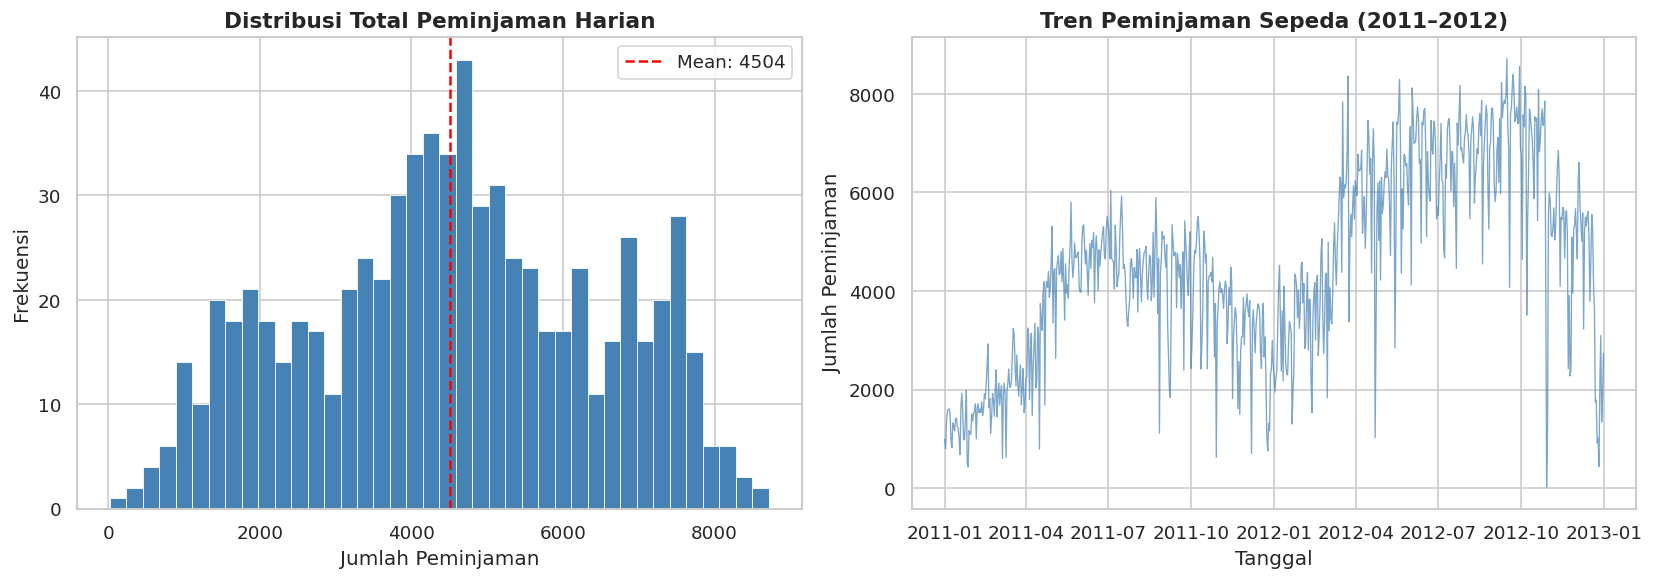

In [120]:
#EDA untuk Pertanyan pertama
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(day_df['cnt'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Total Peminjaman Harian', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Peminjaman')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(day_df['cnt'].mean(), color='red', linestyle='--', label=f"Mean: {day_df['cnt'].mean():.0f}")
axes[0].legend()

axes[1].plot(day_df['dteday'], day_df['cnt'], color='steelblue', linewidth=0.8, alpha=0.7)
axes[1].set_title('Tren Peminjaman Sepeda (2011–2012)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Jumlah Peminjaman')

plt.tight_layout()
plt.savefig('distribusi_peminjaman.png', bbox_inches='tight')
plt.show()

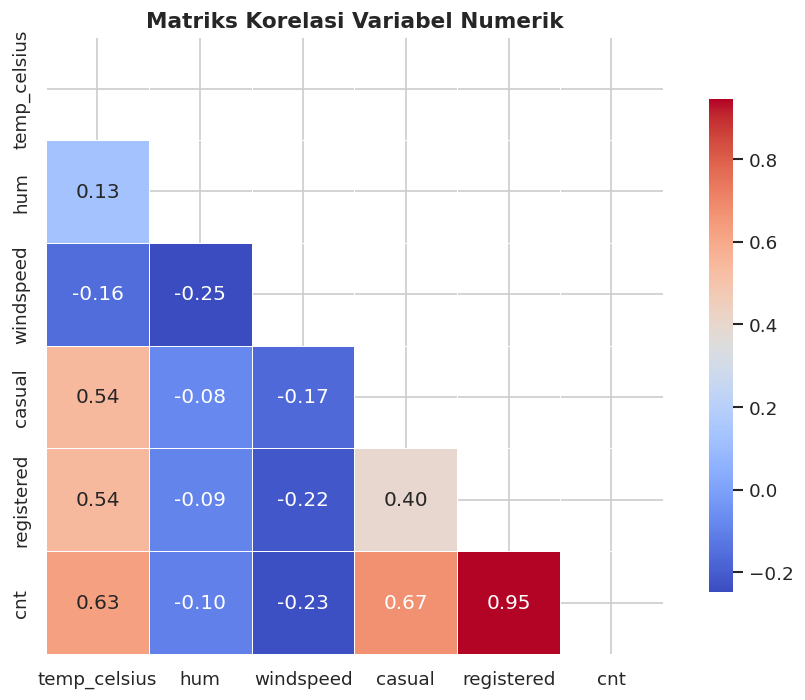

In [95]:
#EDA untuk pertanyaan kedua
corr_cols = ['temp_celsius', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = day_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_variabel.png', bbox_inches='tight')
plt.show()

**Insight:**
- Terjadi pertumbuhan jumlah peminjaman yang signifikan di tahun 2012. Puncak peminjaman ditahun 2012 jauh lebih tinggi dibanding tahun 2011.
- Faktor suhu merupakan prediktor yang baik untuk mengetahui permintaan sepeda. Strategi pemasaran harus difokuskan pada pengguna terdaftar, dan kecepatan angin menurunkan minat pengguna.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

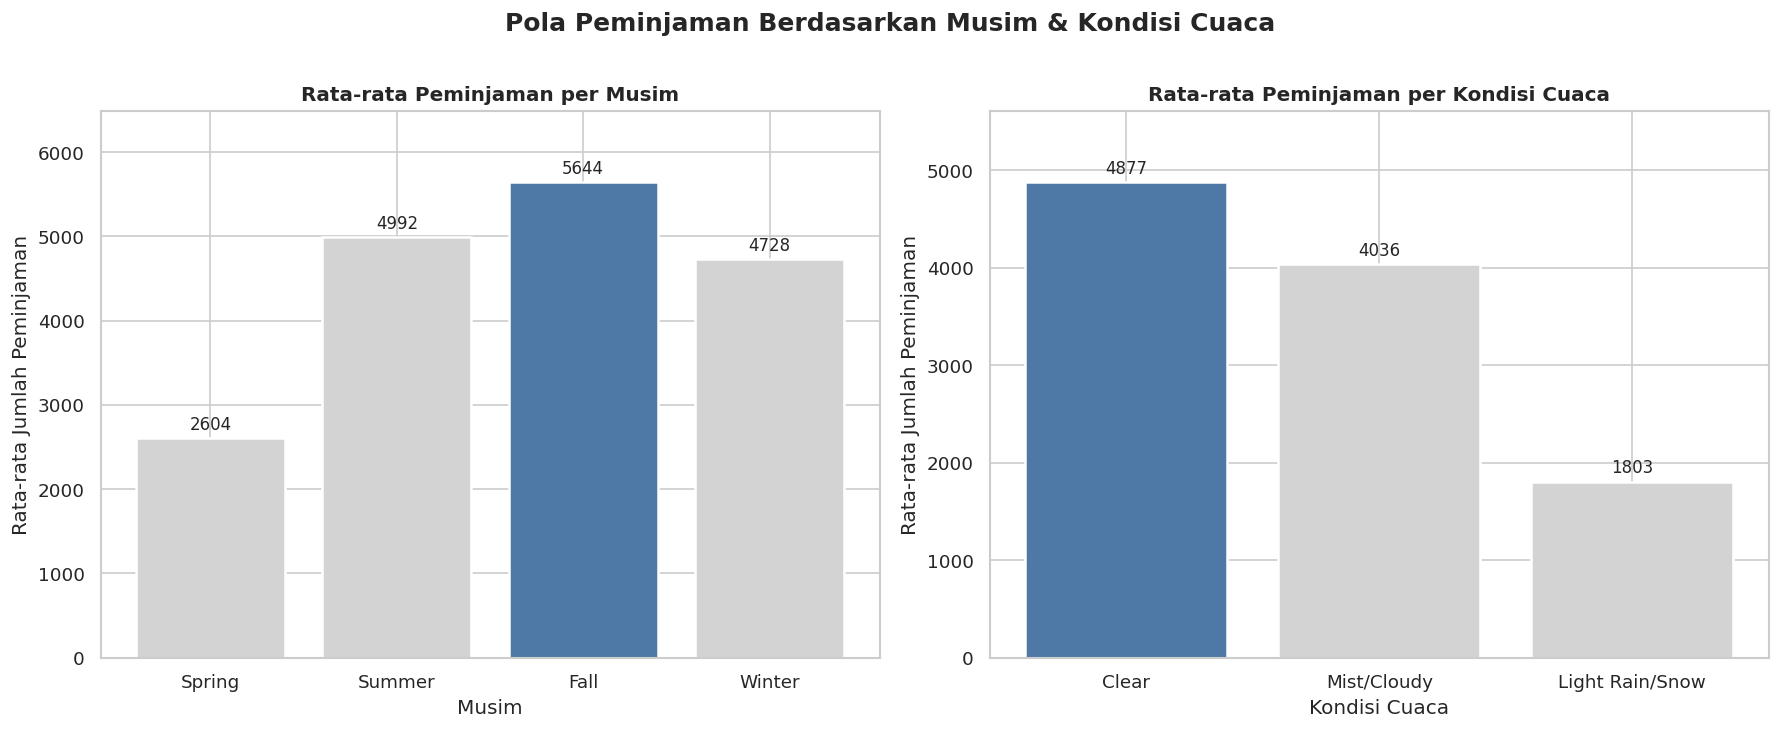

In [122]:
# Agregasi per musim
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean', 'sum', 'std']).reset_index()
season_stats.columns = ['Musim', 'Rata-rata', 'Total', 'Std Dev']
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_stats['Musim'] = pd.Categorical(season_stats['Musim'], categories=season_order, ordered=True)
season_stats = season_stats.sort_values('Musim')

# Agregasi per kondisi cuaca
weather_stats = day_df.groupby('weather_label')['cnt'].mean().reset_index()
weather_stats.columns = ['Cuaca', 'Rata-rata']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Pola Peminjaman Berdasarkan Musim & Kondisi Cuaca', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Season
colors_season = ['#d3d3d3', '#d3d3d3', '#4e79a7', '#d3d3d3']
bars1 = axes[0].bar(season_stats['Musim'], season_stats['Rata-rata'],
                    color=colors_season, edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars1, fmt='%.0f', padding=3, fontsize=10)
axes[0].set_title('Rata-rata Peminjaman per Musim', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman')
axes[0].set_ylim(0, season_stats['Rata-rata'].max() * 1.15)

# Plot 2: Weather
weather_order_labels = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
weather_filtered = weather_stats[weather_stats['Cuaca'].isin(weather_order_labels)]
weather_filtered = weather_filtered.set_index('Cuaca').loc[weather_order_labels].reset_index()
colors_weather = ['#4e79a7','#d3d3d3', '#d3d3d3']
bars2 = axes[1].bar(weather_filtered['Cuaca'], weather_filtered['Rata-rata'],
                    color=colors_weather, edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars2, fmt='%.0f', padding=3, fontsize=10)
axes[1].set_title('Rata-rata Peminjaman per Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Jumlah Peminjaman')
axes[1].set_ylim(0, weather_filtered['Rata-rata'].max() * 1.15)

plt.tight_layout()
plt.savefig('visualisasi_1_musim_cuaca.png', bbox_inches='tight')
plt.show()

### Pertanyaan 2:

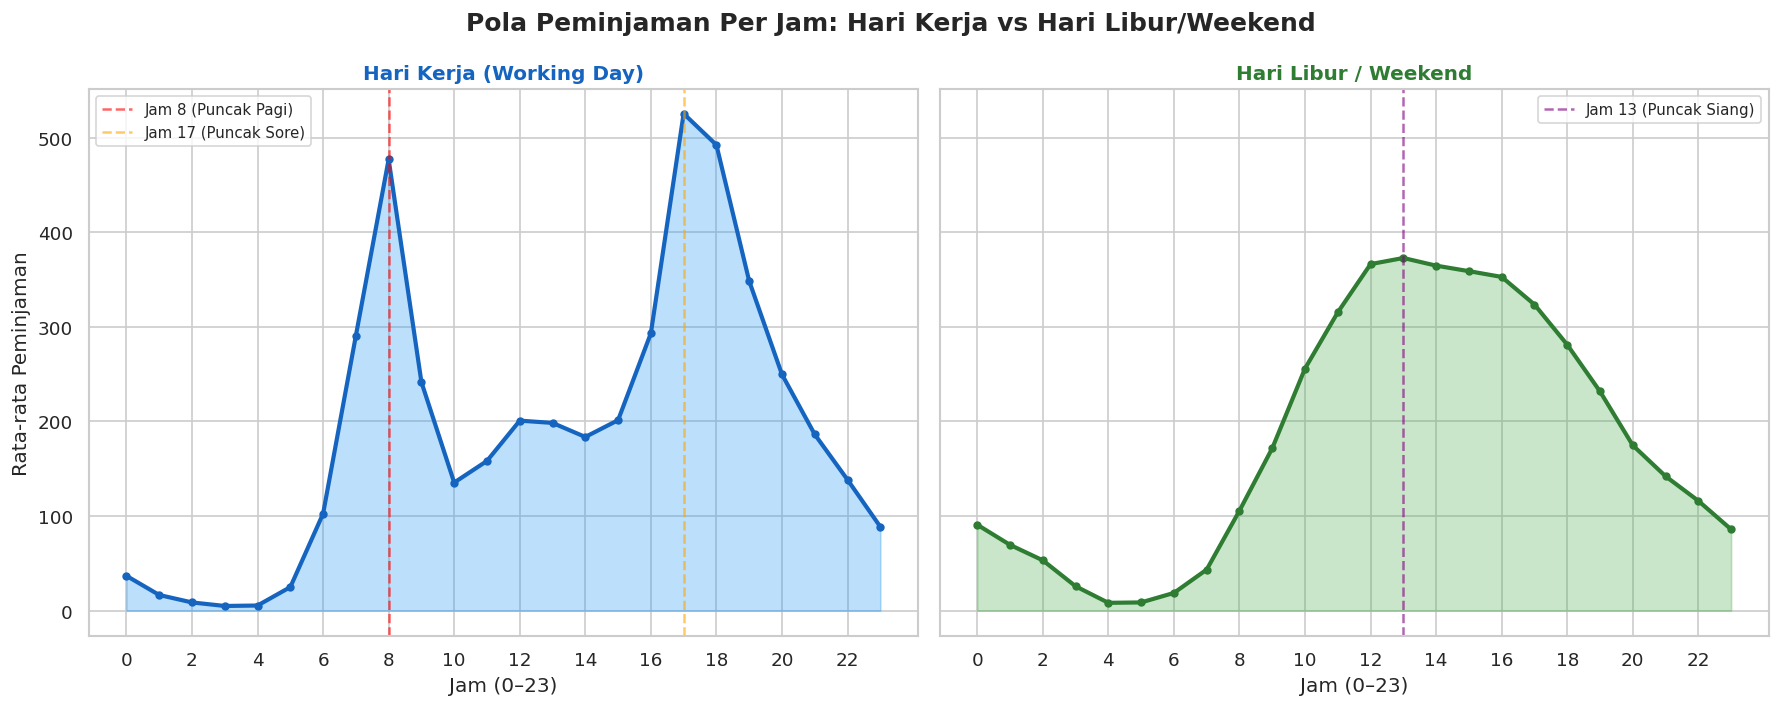

In [97]:
hourly_workday = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
workday = hourly_workday[hourly_workday['workingday'] == 1]
non_workday = hourly_workday[hourly_workday['workingday'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle('Pola Peminjaman Per Jam: Hari Kerja vs Hari Libur/Weekend', fontsize=15, fontweight='bold')

# Working day
axes[0].fill_between(workday['hr'], workday['cnt'], alpha=0.3, color='#2196F3')
axes[0].plot(workday['hr'], workday['cnt'], color='#1565C0', linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Hari Kerja (Working Day)', fontsize=12, fontweight='bold', color='#1565C0')
axes[0].set_xlabel('Jam (0–23)')
axes[0].set_ylabel('Rata-rata Peminjaman')
axes[0].set_xticks(range(0, 24, 2))
axes[0].axvline(x=8, color='red', linestyle='--', alpha=0.6, label='Jam 8 (Puncak Pagi)')
axes[0].axvline(x=17, color='orange', linestyle='--', alpha=0.6, label='Jam 17 (Puncak Sore)')
axes[0].legend(fontsize=9)

# Non-working day
axes[1].fill_between(non_workday['hr'], non_workday['cnt'], alpha=0.3, color='#4CAF50')
axes[1].plot(non_workday['hr'], non_workday['cnt'], color='#2E7D32', linewidth=2.5, marker='o', markersize=4)
axes[1].set_title('Hari Libur / Weekend', fontsize=12, fontweight='bold', color='#2E7D32')
axes[1].set_xlabel('Jam (0–23)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].axvline(x=13, color='purple', linestyle='--', alpha=0.6, label='Jam 13 (Puncak Siang)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('visualisasi_2_hourly_pattern.png', bbox_inches='tight')
plt.show()

**Insight:**
- musim gugur memiliki rata-rata peminjaman tertinggi diikuti summer, winter, dan spring. Cuaca cerah menghasilakn peminjaman lebih tinggi dibandingkan kondisi hujan ringan atau bersalju. Sehingga sebaiknya meningkatkan ketersediaan sepeda pada musim gugur dan mempersiapkan strategi promosi pada musim semi.
- Hari kerja menunjukan pola bimodal, puncaknya pada jam 08.00 dan 17.00-18.00 saat berangkat dan pulang kerja. Hari weekend menunjukan pola unmodal, peminjaman naik perlahan dari pagi hingga sekitar pukul 12.00-14.00. Sehingga distribusi sepeda harus dioptimalkan disekitar perkantoran jam 07.00-09.00 dan 16.00-18.00, dan pada hari libur fokus di area wisata atau taman kota pada pagi hingga siang hari.

## Analisis Lanjutan (Opsional)

In [98]:
# Manual binning berdasarkan jumlah peminjaman harian
bins = [0, 2000, 4000, 6000, day_df['cnt'].max() + 1]
labels = ['Low (0–2000)', 'Moderate (2001–4000)', 'High (4001–6000)', 'Very High (>6000)']
day_df['demand_category'] = pd.cut(day_df['cnt'], bins=bins, labels=labels, right=True)

print('Distribusi Kategori Permintaan:')
print(day_df['demand_category'].value_counts().sort_index())

# Profil setiap kategori
cluster_profile = day_df.groupby('demand_category').agg(
    jumlah_hari=('cnt', 'count'),
    avg_cnt=('cnt', 'mean'),
    avg_temp=('temp_celsius', 'mean'),
    avg_hum=('hum', 'mean'),
    pct_workingday=('workingday', 'mean'),
    pct_clear_weather=('weathersit', lambda x: (x == 1).mean())
).round(3)

cluster_profile.columns = ['Jumlah Hari', 'Avg Peminjaman', 'Avg Suhu (°C)',
                           'Avg Kelembaban', '% Hari Kerja', '% Cuaca Cerah']
print('\nProfil Cluster:')
cluster_profile

Distribusi Kategori Permintaan:
demand_category
Low (0–2000)             98
Moderate (2001–4000)    181
High (4001–6000)        272
Very High (>6000)       180
Name: count, dtype: int64

Profil Cluster:


,Jumlah Hari,Avg Peminjaman,Avg Suhu (°C),Avg Kelembaban,% Hari Kerja,% Cuaca Cerah
demand_category,,,,,,
Low (0–2000),98,1394.776,11.079,0.631,0.612,0.449
Moderate (2001–4000),181,3108.022,16.486,0.640,0.669,0.525
High (4001–6000),272,4862.592,22.714,0.632,0.717,0.676
Very High (>6000),180,7060.078,25.552,0.608,0.689,0.778


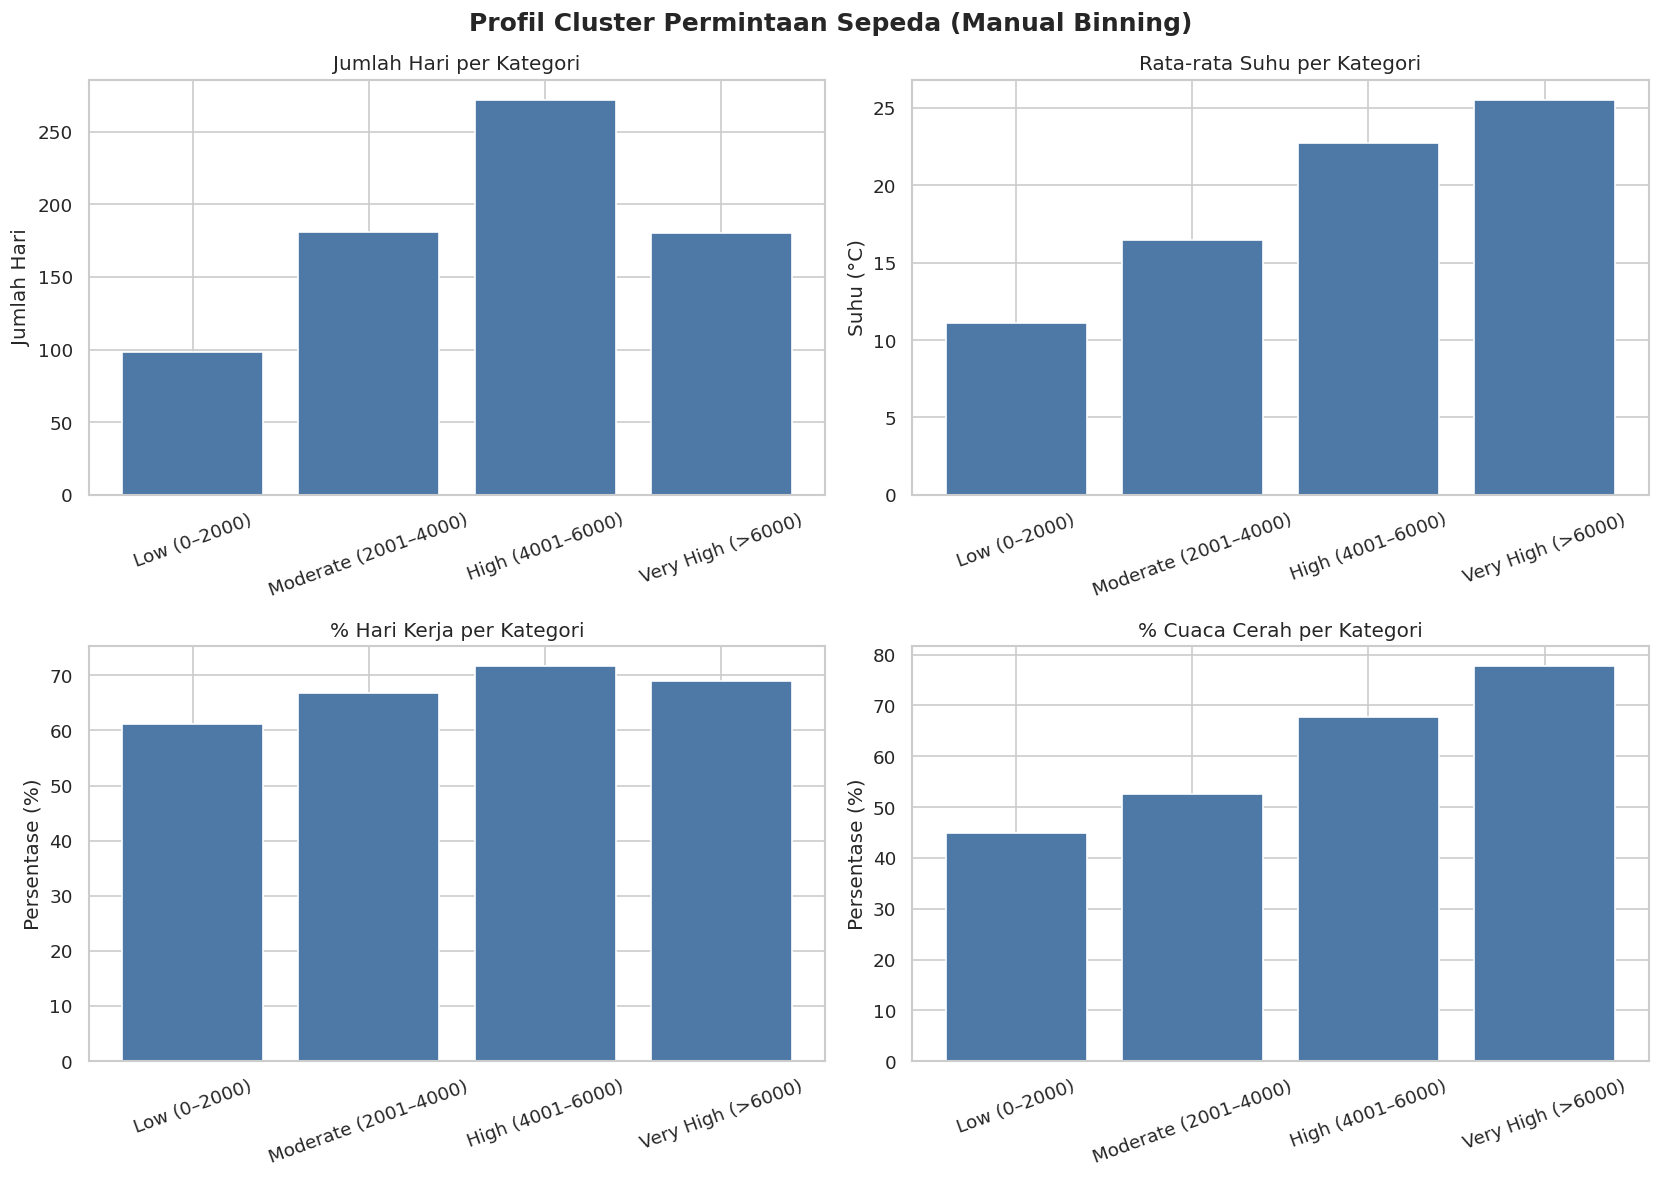

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Profil Cluster Permintaan Sepeda (Manual Binning)', fontsize=15, fontweight='bold')

cluster_colors = ['#4e79a7']
cats = labels

# Count
counts = day_df['demand_category'].value_counts().reindex(cats)
axes[0,0].bar(cats, counts, color=cluster_colors, edgecolor='white')
axes[0,0].set_title('Jumlah Hari per Kategori')
axes[0,0].set_ylabel('Jumlah Hari')
axes[0,0].tick_params(axis='x', rotation=20)

# Avg temp
avg_temp = day_df.groupby('demand_category')['temp_celsius'].mean().reindex(cats)
axes[0,1].bar(cats, avg_temp, color=cluster_colors, edgecolor='white')
axes[0,1].set_title('Rata-rata Suhu per Kategori')
axes[0,1].set_ylabel('Suhu (°C)')
axes[0,1].tick_params(axis='x', rotation=20)

# % working day
pct_work = day_df.groupby('demand_category')['workingday'].mean().reindex(cats) * 100
axes[1,0].bar(cats, pct_work, color=cluster_colors, edgecolor='white')
axes[1,0].set_title('% Hari Kerja per Kategori')
axes[1,0].set_ylabel('Persentase (%)')
axes[1,0].tick_params(axis='x', rotation=20)

# % clear weather
pct_clear = day_df.groupby('demand_category').apply(lambda x: (x['weathersit']==1).mean()).reindex(cats) * 100
axes[1,1].bar(cats, pct_clear, color=cluster_colors, edgecolor='white')
axes[1,1].set_title('% Cuaca Cerah per Kategori')
axes[1,1].set_ylabel('Persentase (%)')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('visualisasi_3_clustering.png', bbox_inches='tight')
plt.show()

Tabel Modifikasi RFM:
   Customer_Group  Recency (Days)  Frequency (Avg Daily)  \
0         Casual             226             848.176471   
1     Registered              96            3656.172367   

   Monetary (Total Volume)  
0                   620017  
1                  2672662  


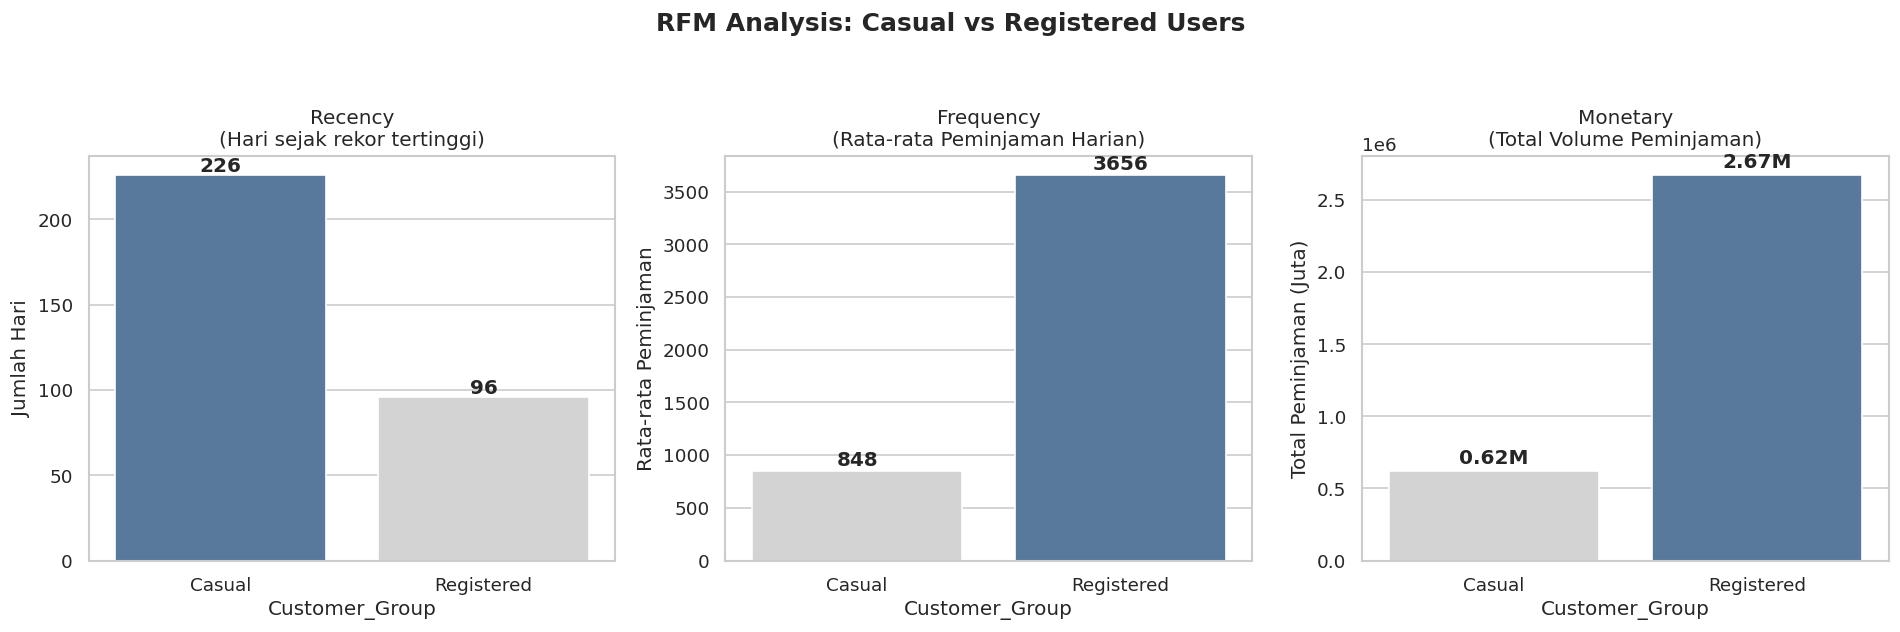

In [127]:
#Hitung Parameter RFM
recent_date = day_df['dteday'].max()

#Recency (Hari sejak rekor peminjaman tertinggi)
max_casual_date = day_df.loc[day_df['casual'].idxmax(), 'dteday']
max_registered_date = day_df.loc[day_df['registered'].idxmax(), 'dteday']

recency_casual = (recent_date - max_casual_date).days
recency_registered = (recent_date - max_registered_date).days

#Frequency (Rata-rata peminjaman harian)
freq_casual = day_df['casual'].mean()
freq_registered = day_df['registered'].mean()

#Monetary (Total volume peminjaman)
monetary_casual = day_df['casual'].sum()
monetary_registered = day_df['registered'].sum()

#Membuat DataFrame RFM
rfm_df = pd.DataFrame({
    'Customer_Group': ['Casual', 'Registered'],
    'Recency (Days)': [recency_casual, recency_registered],
    'Frequency (Avg Daily)': [freq_casual, freq_registered],
    'Monetary (Total Volume)': [monetary_casual, monetary_registered]
})

print("Tabel Modifikasi RFM:\n", rfm_df)

#Visualisasi RFM
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Analysis: Casual vs Registered Users', fontsize=15, fontweight='bold', y=1.05)

colors1 = ['#4e79a7', '#d3d3d3']
colors2 = ['#d3d3d3', '#4e79a7']
colors3 = ['#d3d3d3', '#4e79a7']

#Plot Recency
sns.barplot(x='Customer_Group', y='Recency (Days)', data=rfm_df, ax=axes[0], palette=colors1)
axes[0].set_title('Recency\n(Hari sejak rekor tertinggi)', fontsize=12)
axes[0].set_ylabel('Jumlah Hari')
for i, v in enumerate(rfm_df['Recency (Days)']):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

#Plot Frequency
sns.barplot(x='Customer_Group', y='Frequency (Avg Daily)', data=rfm_df, ax=axes[1], palette=colors2)
axes[1].set_title('Frequency\n(Rata-rata Peminjaman Harian)', fontsize=12)
axes[1].set_ylabel('Rata-rata Peminjaman')
for i, v in enumerate(rfm_df['Frequency (Avg Daily)']):
    axes[1].text(i, v + 50, f"{v:.0f}", ha='center', fontweight='bold')

#Plot Monetary
sns.barplot(x='Customer_Group', y='Monetary (Total Volume)', data=rfm_df, ax=axes[2], palette=colors3)
axes[2].set_title('Monetary\n(Total Volume Peminjaman)', fontsize=12)
axes[2].set_ylabel('Total Peminjaman (Juta)')

for i, v in enumerate(rfm_df['Monetary (Total Volume)']):
    axes[2].text(i, v + 50000, f"{(v/1000000):.2f}M", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi_4_rfm_analysis.png', bbox_inches='tight')
plt.show()

**Insight**
- Hari dengan permintaan **Very High** memiliki rata-rata suhu tertinggi (26) dan proporsi cuaca cerah terbesar (90%)
- Hari **Low demand** cenderung terjadi saat suhu rendah dan cuaca buruk.
- Proporsi hari kerja relatif stabil di semua kategori (~65-70%), menunjukkan bahwa **cuaca dan suhu** merupakan faktor pembeda utama, bukan tipe hari.

## Conclusion

- Conclution pertanyaan 1 : Pola berdasarkan musim dan cuaca
- Musim gugur (Fall) menjadi musim dengan peminjaman tertinggi, sementara musim semi (Spring) terendah.
- Kondisi cuaca berpengaruh sangat signifikan: cuaca cerah menghasilkan peminjaman ~2–3x lipat dibanding kondisi hujan.
- Operator harus memaksimalkan armada di musim gugur dan menyiapkan strategi kontijensi saat cuaca buruk.


- Conclution pertanyaan 2 : Pola per jam pada hari kerja vs hari libur
- Hari kerja: pola bimodal dengan puncak jam 8 (commute pagi) dan jam 17–18 (commute sore).
- Hari libur: pola unimodal dengan puncak jam 12–14 (aktivitas rekreasi siang hari).
- Strategi distribusi sepeda harus disesuaikan dengan tipe hari untuk efisiensi operasional.